In [67]:
from xaikd import models, datasets
from torchvision import transforms as T
from PIL import Image


from xaikd import utils
from xaikd.utils import metrics

import numpy as np

from matplotlib import pyplot as plt

import pandas as pd

from tqdm import tqdm

In [2]:
device = utils.get_device()
device

'cuda'

In [3]:
model = models.get_model('cifar100-resnet18-p1')

model.to(device);

In [4]:
dataset = datasets.construct("cifar100")

In [5]:
train_ld = datasets.subsample_dataset(
    dataset.create_subset(train_split=True),
    ratio=0.1,
    seed=1
)

In [6]:
train_ld.dataset.transform

Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
)

In [7]:
class SaltPepperCorruption(object):
    def __init__(self, severity_level: float):
        self.severity_level = severity_level

    def __call__(self, img: Image) -> Image:
        img = np.array(img)

        h, w, c = img.shape

        # we flip those pixels whose values below threshold
        binmask = np.random.rand(h, w, 1) > self.severity_level

        # we choose black (pepper)and white (salt).
        noisepixels = (np.random.rand(h, w, 1) > 0.5) * 255

        output = np.where(binmask, img, noisepixels)

        # we output PIL.Image to make the output compatible with test_transform,
        # which contains [ToTensor(), Normalization()]
        # This is similar to __getitem__(...) of
        # https://pytorch.org/vision/master/_modules/torchvision/datasets/cifar.html#CIFAR10
        return Image.fromarray(output.astype("uint8"))

In [110]:
def accuracy_at_different_corruption_level(model, level):
    
    val_ds = dataset.create_subset(train_split=False)
    val_ds.transform = T.Compose([
        SaltPepperCorruption(level),
        val_ds.transform
    ])
    
    
    dl = datasets.build_dataloader(val_ds, shuffle=False)
    
    return dict(corruption_level=level, acc=metrics.accuracy(model, dl,num_classes=100, device=device))

accuracy_at_different_corruption_level(model, 0.2)

{'corruption_level': 0.2, 'acc': 0.01549999974668026}

In [9]:
for level in [0, 0.01, 0.1, 0.25, 0.5]:
    print(accuracy_at_different_corruption_level(model, level))

{'level': 0, 'acc': 0.6840000152587891}
{'level': 0.01, 'acc': 0.4952000081539154}
{'level': 0.1, 'acc': 0.03720000013709068}
{'level': 0.25, 'acc': 0.013700000010430813}
{'level': 0.5, 'acc': 0.012600000016391277}


# Extract Activation and Context Vectors

In [10]:
import torch
from torch.nn import functional as F 

In [11]:
torch.zeros_like

<function torch._VariableFunctionsClass.zeros_like>

In [120]:
def logit_mod_exceeding_evidence(logits, targets):
    preds = torch.argmax(logits, dim=1)
    
    ix = np.arange(logits.shape[0])
        
    new_logits = torch.zeros_like(logits).to(logits.device)
    
    new_logits[ix, preds] = logits[ix, preds]
    new_logits[ix, targets] = - logits[ix, targets]
    
    
    return new_logits * (new_logits.sum(dim=1, keepdims=True) > 0) 

@torch.no_grad()
def sanity_check():
    output = logit_mod_exceeding_evidence(
        torch.tensor([
            # wrong prediction
            [0.8, 0.12, 0.9],
            [-0.8, 0.1, 0.2],
            # correct prediction
            [0.8, 0.1, 0.2],
            [-0.8, 0.1, 0.2],
        ]),
        torch.tensor([
            0,
            1,
            0,
            2
        ])    
    ).detach().numpy()
    
    np.testing.assert_allclose(
        output,
        [
            [-0.8, 0., 0.9],
            [0, -0.1, 0.2],
            [0, 0, 0],
            [0, 0, 0]
        ]
    )
    print("sanity check passed!")
    
sanity_check()

sanity check passed!


In [135]:
def logit_mod_allexceeding_evidence(logits, targets):
    preds = torch.argmax(logits, dim=1)
    
    ix = np.arange(logits.shape[0])
        
    new_logits = torch.zeros_like(logits).to(logits.device)
    
    new_logits[:, ] = F.relu(logits[:, ] - logits[ix, targets].unsqueeze(1))
    
    return new_logits

In [136]:
from xaikd import attributors

In [194]:
CORRUPTION_LEVEL = 0.1
LAYER = "layer3"

In [195]:
def extract_act_ctx_at_layer_with_corruption(model, layer, level):
    
    train_ds = dataset.create_subset(train_split=True)
    
    train_ds.transform = T.Compose([
        SaltPepperCorruption(level),
        train_ds.transform
    ])
    
    
    dl = datasets.build_dataloader(
        datasets.subsample_dataset(
            train_ds,
            ratio=0.1, # we use only 1% of the actual training data for now,
            seed=1
        ),
        shuffle=False
    )
    
     
    act, ctx = attributors.extract_activation_context(
        model, 
        layer=layer,
        dataset=dataset,
        data_loader=dl,
        logit_modifier=logit_mod_allexceeding_evidence,
#         logit_modifier=logit_mod_exceeding_evidence,
        device=device,
        rng=np.random.default_rng(seed=1)
    )
    
#     mean = np.mean(act, axis=0)
    mean = np.zeros(act.shape[1])

    act = act - mean
    
    eigvals, eigvecs = np.linalg.eigh(act.T @ ctx + ctx.T @ act / act.shape[0])
    
    v1 = eigvecs[:, 0]
    
    eigvals = np.flip(eigvals)
    
    eigvecs = np.flip(eigvecs, axis=1)
    
    np.testing.assert_allclose(eigvecs[:, -1], v1)
    
    return eigvals, eigvecs, mean

EIGVALS, EIGVECS, MEAN = extract_act_ctx_at_layer_with_corruption(model, layer=LAYER, level=CORRUPTION_LEVEL)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:17<00:00,  4.53it/s]


layer3: output-dims=torch.Size([256, 8, 8])


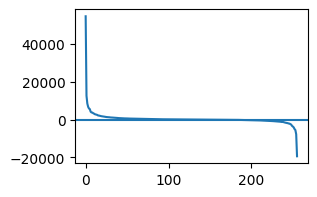

In [196]:
plt.figure(figsize=(3, 2))
plt.plot(EIGVALS)
plt.axhline(0)

In [197]:
def attach_projected_fh(module, U):    
    d = U.shape[0]

    A = torch.from_numpy(np.eye(d) - U@U.T).float().to(device)

    A = A.unsqueeze(2).unsqueeze(3)
    
    mu = torch.from_numpy(MEAN.reshape((1, -1, 1, 1))).float().to(device)
    

    def fh(mod, input, output):
        
        assert isinstance(output, torch.Tensor)

        projected = F.conv2d(
            output, 
            A
        )

        return projected
    
    hook = module.register_forward_hook(fh)

    return hook

def eval_at_k(model, k, layer=LAYER, corruption_level=CORRUPTION_LEVEL):
    
    if layer == "maxpool":
        module == getattr(model, layer)
    else:
        # remark: this [-1] only meant for ResNet
        module = getattr(model, layer)[-1]
    
    try:
        hook = attach_projected_fh(module, EIGVECS[:, :k])
        result = accuracy_at_different_corruption_level(model, corruption_level)
        result["k"] = k
        result["layer"] = layer

        return result
    finally:
        hook.remove()
    
eval_at_k(model, k=0);

In [198]:
for lvl in [0.0, CORRUPTION_LEVEL]:
    print(eval_at_k(model, k=1, corruption_level=lvl))

{'corruption_level': 0.0, 'acc': 0.6251999735832214, 'k': 1, 'layer': 'layer3'}
{'corruption_level': 0.1, 'acc': 0.07079999893903732, 'k': 1, 'layer': 'layer3'}


In [199]:
def eval_at_different_ks(model):
    
    d = EIGVALS.shape[0]
    rows = []
    for k in tqdm(sorted(list(set(list(range(20)) + [d//4, d//2, d])))):
        
        res_corrupt = eval_at_k(model, k, corruption_level=CORRUPTION_LEVEL)
        res_clean = eval_at_k(model, k, corruption_level=0.0)
            
        res = dict(
            k=k,
            acc_clean=res_clean["acc"],
            acc_corrupt=res_corrupt["acc"]
        )
        
        rows.append(res)
        
    
    return pd.DataFrame(rows)


df = eval_at_different_ks(model)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23/23 [02:58<00:00,  7.77s/it]


In [200]:
df

,k,acc_clean,acc_corrupt
0,0,0.6840,0.0364
1,1,0.6252,0.0711
2,2,0.6135,0.0738
3,3,0.6121,0.0721
4,4,0.6096,0.0719
5,5,0.6084,0.0762
6,6,0.6069,0.0710
7,7,0.6055,0.0695
8,8,0.6027,0.0652
9,9,0.5978,0.0694


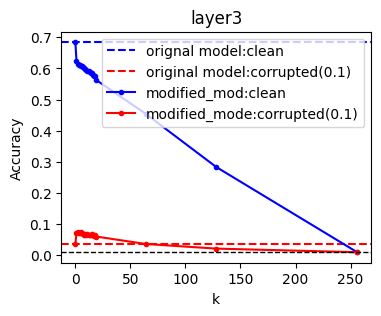

In [201]:
def viz():
    baseline_acc_clean = accuracy_at_different_corruption_level(model, 0.0)["acc"]
    baseline_acc_corrupted = accuracy_at_different_corruption_level(model, CORRUPTION_LEVEL)["acc"]
    plt.figure(figsize=(4, 3))

    plt.title(f"{LAYER}")
    
    plt.ylabel("Accuracy")
    
    plt.axhline(baseline_acc_clean, color="blue", 
                label="orignal model:clean", 
                ls='--'
    )
    plt.axhline(
        baseline_acc_corrupted, 
        color="red", 
        label=f"original model:corrupted({CORRUPTION_LEVEL})", 
        ls="--"
    )

    plt.plot(df.k, 
             df.acc_clean, 
             label="modified_mod:clean",
             marker=".", 
             ls="-", 
             color="blue"
    )    
    plt.plot(df.k, 
             df.acc_corrupt, 
             label=f"modified_mode:corrupted({CORRUPTION_LEVEL})", 
             ls="-", 
             color="red", 
             marker="."
    )
    plt.axhline(1/100, ls="--", lw=1, color="k")
    plt.legend()
    plt.xlabel("k")
viz()

# Results

## With `WiningClassExceed` Modifier (training_size=0.1)
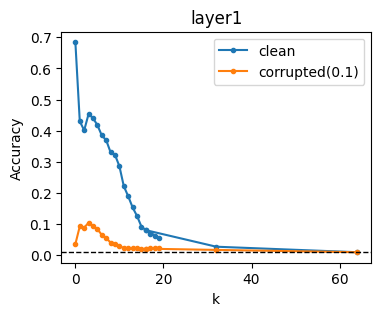
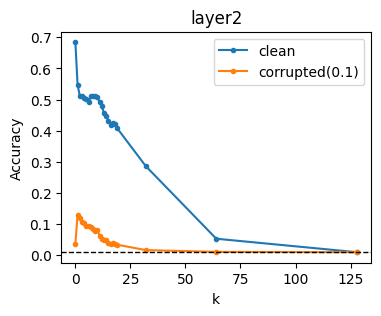
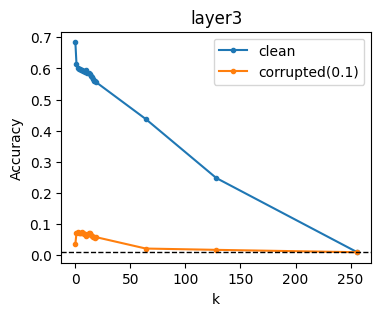
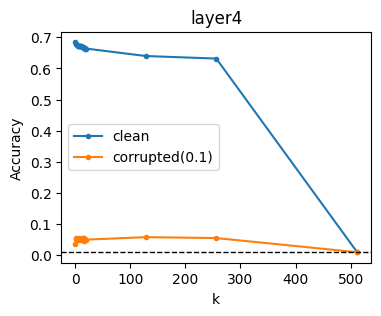


## With `AllExceed` Modifier
### Training Size 0.1
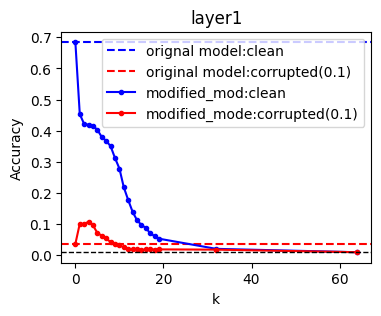
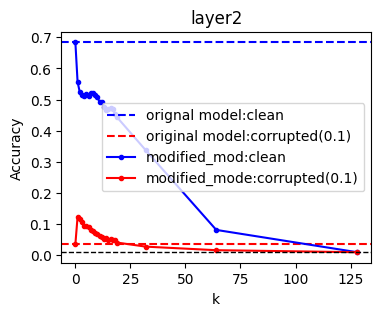

### Training Size 0.5

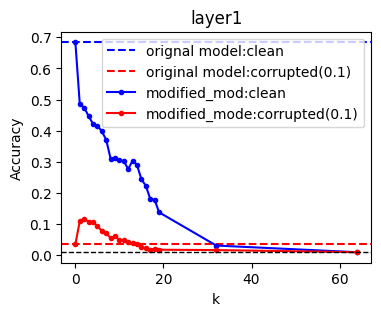